# Internal Wave Analysis - SWOT Unsmoothed SSH Data

This notebook analyzes SWOT L2 LR SSH Unsmoothed data for internal wave signatures in the Andaman Sea.

## Analysis Pipeline:
1. Read corrected SSHA files (cross-swath bias removed)
2. Mask data for Andaman Sea region
3. Apply 2D FFT to detect internal wave wavelengths
4. Analyze spectral characteristics
5. Visualize internal wave patterns

## Internal Waves in Andaman Sea:
- Typical wavelengths: 50-250 km
- Generated at sills and ridges
- Propagate as solitons with amplitudes of 50-150 m (subsurface)
- Surface SSH signature: 5-20 cm

In [2]:
# =============================================================================
# IMPORT LIBRARIES
# =============================================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import signal
from scipy.fft import fft2, fftshift, fftfreq
from scipy.ndimage import gaussian_filter
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# Import our cross-swath correction module
import sys
sys.path.insert(0, r"C:\Users\abhik\Desktop\project related work")
from swot_crossswath_correction import process_file, extract_region

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


In [3]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Input folder with SWOT Unsmoothed files
DATA_FOLDER = r"C:\Users\abhik\Downloads\SWOT_L2_LR_SSH_2.0_2.0-20260120_114612"

# Andaman Sea region bounds
LAT_MIN, LAT_MAX = 5.0, 20.0
LON_MIN, LON_MAX = 92.0, 100.0

# SWOT pixel resolution (approximately)
PIXEL_RESOLUTION_M = 250  # 250m for unsmoothed product

# Internal wave detection parameters
# Andaman Sea internal waves typically have wavelengths of 50-250 km
MIN_WAVELENGTH_KM = 10   # Minimum wavelength to analyze
MAX_WAVELENGTH_KM = 300  # Maximum wavelength to analyze

print("=" * 70)
print("INTERNAL WAVE ANALYSIS CONFIGURATION")
print("=" * 70)
print(f"Data folder: {DATA_FOLDER}")
print(f"Region: Andaman Sea ({LAT_MIN}°-{LAT_MAX}°N, {LON_MIN}°-{LON_MAX}°E)")
print(f"Pixel resolution: {PIXEL_RESOLUTION_M} m")
print(f"Target wavelengths: {MIN_WAVELENGTH_KM}-{MAX_WAVELENGTH_KM} km")
print("=" * 70)

INTERNAL WAVE ANALYSIS CONFIGURATION
Data folder: C:\Users\abhik\Downloads\SWOT_L2_LR_SSH_2.0_2.0-20260120_114612
Region: Andaman Sea (5.0°-20.0°N, 92.0°-100.0°E)
Pixel resolution: 250 m
Target wavelengths: 10-300 km


In [4]:
# =============================================================================
# LOAD AND PROCESS A SINGLE FILE
# =============================================================================

# Find all unsmoothed files
files = sorted(glob.glob(os.path.join(DATA_FOLDER, "*.nc")))
print(f"Found {len(files)} files")

# Select a file for analysis (use first file or specify index)
file_idx = 0
filepath = files[file_idx]
filename = os.path.basename(filepath)

print(f"\nAnalyzing: {filename}")

# Process file with cross-swath bias correction
result = process_file(
    filepath,
    lat_bounds=(LAT_MIN, LAT_MAX),
    apply_ocean_mask=True,
    return_datasets=True
)

print(f"\n✓ File processed successfully!")
print(f"  Cycle: {result['metadata']['cycle_number']}")
print(f"  Pass: {result['metadata']['pass_number']}")
print(f"  Left swath points: {result['left']['valid_points']:,}")
print(f"  Right swath points: {result['right']['valid_points']:,}")

Found 35 files

Analyzing: SWOT_L2_LR_SSH_Unsmoothed_002_077_20230813T192851_20230813T202018_PGC0_01.nc

✓ File processed successfully!
  Cycle: 2
  Pass: 77
  Left swath points: 10,524,820
  Right swath points: 10,234,712


In [5]:
# =============================================================================
# EXTRACT ANDAMAN SEA REGION DATA
# =============================================================================

def extract_regional_grid(result, lat_bounds, lon_bounds, swath='left'):
    """
    Extract data for a specific region and return as 2D arrays.
    """
    data = result[swath]
    lat = data['lat']
    lon = data['lon']
    ssha = data['ssha_corrected']
    
    # Create regional mask
    lat_min, lat_max = lat_bounds
    lon_min, lon_max = lon_bounds
    
    region_mask = (lat >= lat_min) & (lat <= lat_max) & \
                  (lon >= lon_min) & (lon <= lon_max)
    
    # Find row indices that have data in region
    row_has_data = np.any(region_mask & ~np.isnan(ssha), axis=1)
    
    if np.sum(row_has_data) < 10:
        return None, None, None, None
    
    # Extract rows with regional data
    first_row = np.argmax(row_has_data)
    last_row = len(row_has_data) - np.argmax(row_has_data[::-1])
    
    lat_region = lat[first_row:last_row, :]
    lon_region = lon[first_row:last_row, :]
    ssha_region = ssha[first_row:last_row, :]
    
    # Apply region mask to extracted data
    region_mask_sub = (lat_region >= lat_min) & (lat_region <= lat_max) & \
                      (lon_region >= lon_min) & (lon_region <= lon_max)
    ssha_masked = np.where(region_mask_sub, ssha_region, np.nan)
    
    return lat_region, lon_region, ssha_masked, data['cross_track_dist'][first_row:last_row, :]

# Extract data for both swaths
regional_data = {}

for swath in ['left', 'right']:
    lat, lon, ssha, ctd = extract_regional_grid(
        result, 
        (LAT_MIN, LAT_MAX), 
        (LON_MIN, LON_MAX), 
        swath
    )
    
    if ssha is not None:
        valid_count = np.sum(~np.isnan(ssha))
        regional_data[swath] = {
            'lat': lat,
            'lon': lon,
            'ssha': ssha,
            'cross_track_dist': ctd
        }
        print(f"{swath.upper()} swath: {ssha.shape}, {valid_count:,} valid points")
        print(f"  Lat range: {np.nanmin(lat):.2f}° to {np.nanmax(lat):.2f}°")
        print(f"  SSHA range: {np.nanmin(ssha)*100:.1f} to {np.nanmax(ssha)*100:.1f} cm")
    else:
        print(f"{swath.upper()} swath: No data in region")

LEFT swath: (4440, 240), 967,696 valid points
  Lat range: 5.12° to 14.56°
  SSHA range: -418.9 to 581.1 cm
RIGHT swath: (3973, 240), 815,226 valid points
  Lat range: 5.07° to 13.51°
  SSHA range: -432.0 to 580.2 cm


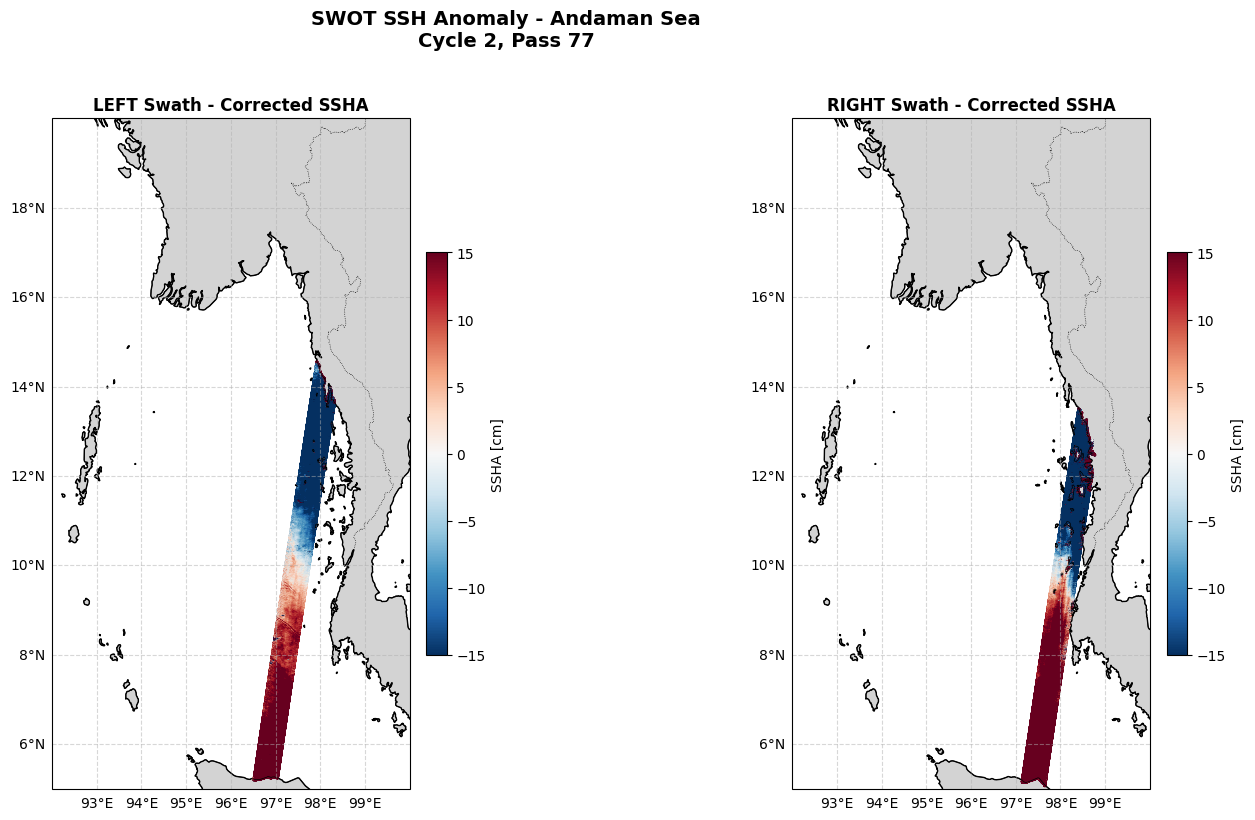

In [6]:
# =============================================================================
# VISUALIZE SSHA IN ANDAMAN SEA REGION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 8), 
                          subplot_kw=dict(projection=ccrs.PlateCarree()))

for idx, swath in enumerate(['left', 'right']):
    ax = axes[idx]
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    
    if swath in regional_data:
        data = regional_data[swath]
        lat, lon, ssha = data['lat'], data['lon'], data['ssha']
        
        # Plot SSHA
        valid = ~np.isnan(ssha)
        sc = ax.scatter(lon[valid], lat[valid], 
                        c=ssha[valid]*100, s=0.5, cmap='RdBu_r',
                        vmin=-15, vmax=15, transform=ccrs.PlateCarree())
        
        cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.02)
        cbar.set_label('SSHA [cm]')
    
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])
    ax.set_title(f'{swath.upper()} Swath - Corrected SSHA', fontsize=12, fontweight='bold')
    gl = ax.gridlines(draw_labels=True, alpha=0.5, linestyle='--')
    gl.right_labels = gl.top_labels = False

plt.suptitle(f'SWOT SSH Anomaly - Andaman Sea\n'
             f'Cycle {result["metadata"]["cycle_number"]}, Pass {result["metadata"]["pass_number"]}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# =============================================================================
# FFT ANALYSIS FOR INTERNAL WAVE DETECTION
# =============================================================================

def analyze_internal_waves_fft(ssha, pixel_resolution_m=250, 
                                min_wavelength_km=10, max_wavelength_km=300):
    """
    Perform 2D FFT analysis to detect internal wave signatures.
    
    Parameters:
    -----------
    ssha : np.ndarray
        2D array of SSH anomaly (num_lines x num_pixels)
    pixel_resolution_m : float
        Pixel resolution in meters
    min_wavelength_km : float
        Minimum wavelength to analyze (km)
    max_wavelength_km : float
        Maximum wavelength to analyze (km)
        
    Returns:
    --------
    dict : FFT results including power spectrum, wavelengths, etc.
    """
    # Replace NaN with 0 for FFT (or use interpolation)
    ssha_filled = np.nan_to_num(ssha, nan=0.0)
    
    # Apply window to reduce spectral leakage
    window_along = signal.windows.hann(ssha_filled.shape[0])
    window_across = signal.windows.hann(ssha_filled.shape[1])
    window_2d = np.outer(window_along, window_across)
    ssha_windowed = ssha_filled * window_2d
    
    # Compute 2D FFT
    fft_result = fft2(ssha_windowed)
    fft_shifted = fftshift(fft_result)
    
    # Power spectrum
    power_spectrum = np.abs(fft_shifted) ** 2
    
    # Compute frequency axes
    n_along, n_across = ssha.shape
    
    # Spatial frequencies (cycles per meter)
    freq_along = fftshift(fftfreq(n_along, d=pixel_resolution_m))
    freq_across = fftshift(fftfreq(n_across, d=pixel_resolution_m))
    
    # Convert to wavelengths (km)
    with np.errstate(divide='ignore', invalid='ignore'):
        wavelength_along = np.where(freq_along != 0, 1 / np.abs(freq_along) / 1000, np.inf)
        wavelength_across = np.where(freq_across != 0, 1 / np.abs(freq_across) / 1000, np.inf)
    
    # Create 2D wavelength grid (radial)
    freq_along_2d, freq_across_2d = np.meshgrid(freq_along, freq_across, indexing='ij')
    freq_radial = np.sqrt(freq_along_2d**2 + freq_across_2d**2)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        wavelength_radial = np.where(freq_radial != 0, 1 / freq_radial / 1000, np.inf)
    
    # Mask for internal wave wavelength range
    iw_mask = (wavelength_radial >= min_wavelength_km) & (wavelength_radial <= max_wavelength_km)
    
    # Calculate 1D radial power spectrum (azimuthally averaged)
    n_bins = min(n_along, n_across) // 2
    freq_bins = np.linspace(0, np.max(freq_radial), n_bins)
    radial_power = np.zeros(n_bins - 1)
    radial_freq = np.zeros(n_bins - 1)
    
    for i in range(n_bins - 1):
        mask = (freq_radial >= freq_bins[i]) & (freq_radial < freq_bins[i+1])
        if np.sum(mask) > 0:
            radial_power[i] = np.mean(power_spectrum[mask])
            radial_freq[i] = (freq_bins[i] + freq_bins[i+1]) / 2
    
    # Convert to wavelength
    with np.errstate(divide='ignore', invalid='ignore'):
        radial_wavelength = np.where(radial_freq != 0, 1 / radial_freq / 1000, np.inf)
    
    return {
        'power_spectrum_2d': power_spectrum,
        'freq_along': freq_along,
        'freq_across': freq_across,
        'wavelength_along': wavelength_along,
        'wavelength_across': wavelength_across,
        'wavelength_radial': wavelength_radial,
        'radial_power': radial_power,
        'radial_wavelength': radial_wavelength,
        'iw_mask': iw_mask,
        'iw_power': np.sum(power_spectrum[iw_mask]),
        'total_power': np.sum(power_spectrum)
    }

# Analyze both swaths
fft_results = {}

for swath in regional_data:
    print(f"\nAnalyzing {swath.upper()} swath...")
    ssha = regional_data[swath]['ssha']
    
    fft_result = analyze_internal_waves_fft(
        ssha,
        pixel_resolution_m=PIXEL_RESOLUTION_M,
        min_wavelength_km=MIN_WAVELENGTH_KM,
        max_wavelength_km=MAX_WAVELENGTH_KM
    )
    
    fft_results[swath] = fft_result
    
    iw_fraction = fft_result['iw_power'] / fft_result['total_power'] * 100
    print(f"  Internal wave band power: {iw_fraction:.1f}% of total")

print("\n✓ FFT analysis complete!")


Analyzing LEFT swath...
  Internal wave band power: 26.7% of total

Analyzing RIGHT swath...
  Internal wave band power: 26.7% of total

✓ FFT analysis complete!


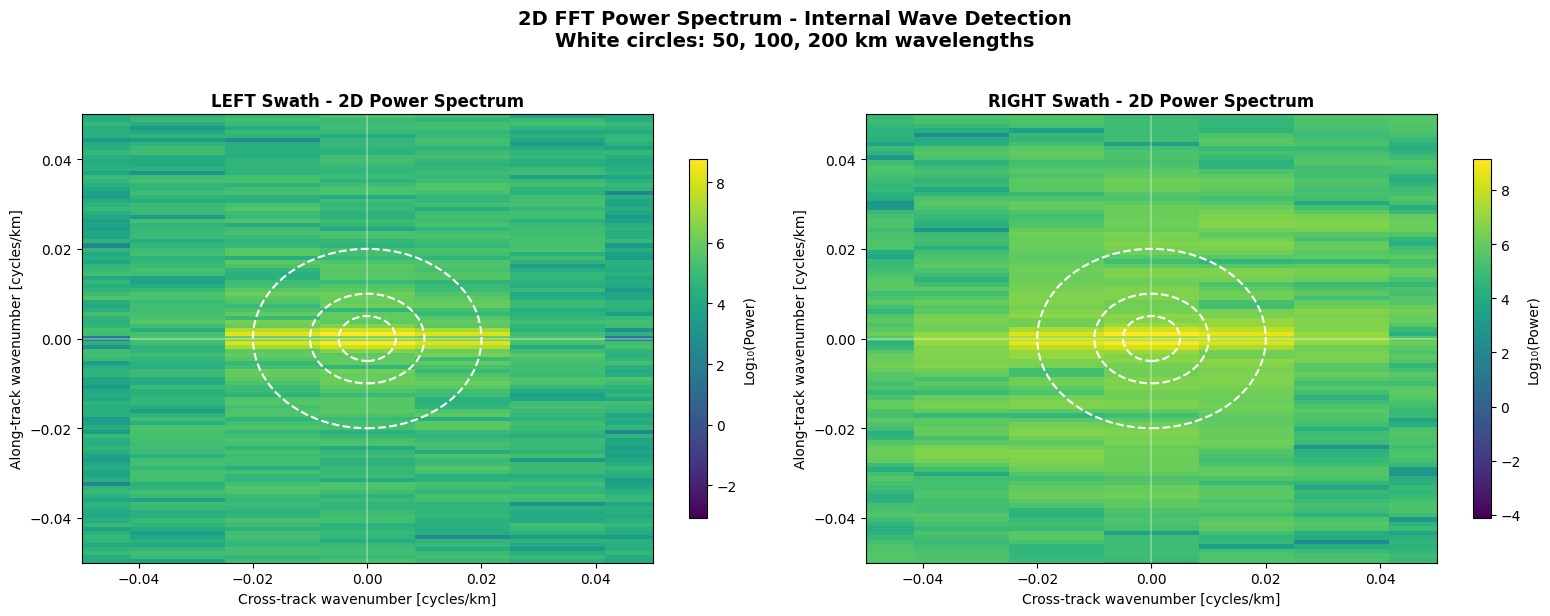

In [8]:
# =============================================================================
# VISUALIZE 2D POWER SPECTRUM
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, swath in enumerate(fft_results):
    ax = axes[idx]
    fft_res = fft_results[swath]
    
    # Plot log power spectrum
    power = fft_res['power_spectrum_2d']
    log_power = np.log10(power + 1e-20)  # Avoid log(0)
    
    # Create extent for plotting (in km^-1)
    freq_along = fft_res['freq_along'] * 1000  # Convert to cycles/km
    freq_across = fft_res['freq_across'] * 1000
    extent = [freq_across[0], freq_across[-1], freq_along[0], freq_along[-1]]
    
    im = ax.imshow(log_power, extent=extent, origin='lower', 
                   cmap='viridis', aspect='auto')
    
    # Add circles for reference wavelengths
    for wl_km in [50, 100, 200]:
        freq_km = 1 / wl_km  # cycles/km
        circle = plt.Circle((0, 0), freq_km, fill=False, color='white', 
                            linestyle='--', linewidth=1.5, label=f'{wl_km} km')
        ax.add_patch(circle)
    
    ax.set_xlim(-0.05, 0.05)
    ax.set_ylim(-0.05, 0.05)
    ax.set_xlabel('Cross-track wavenumber [cycles/km]', fontsize=10)
    ax.set_ylabel('Along-track wavenumber [cycles/km]', fontsize=10)
    ax.set_title(f'{swath.upper()} Swath - 2D Power Spectrum', fontsize=12, fontweight='bold')
    ax.axhline(y=0, color='white', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='white', linestyle='-', alpha=0.3)
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Log₁₀(Power)')

plt.suptitle('2D FFT Power Spectrum - Internal Wave Detection\n'
             'White circles: 50, 100, 200 km wavelengths',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

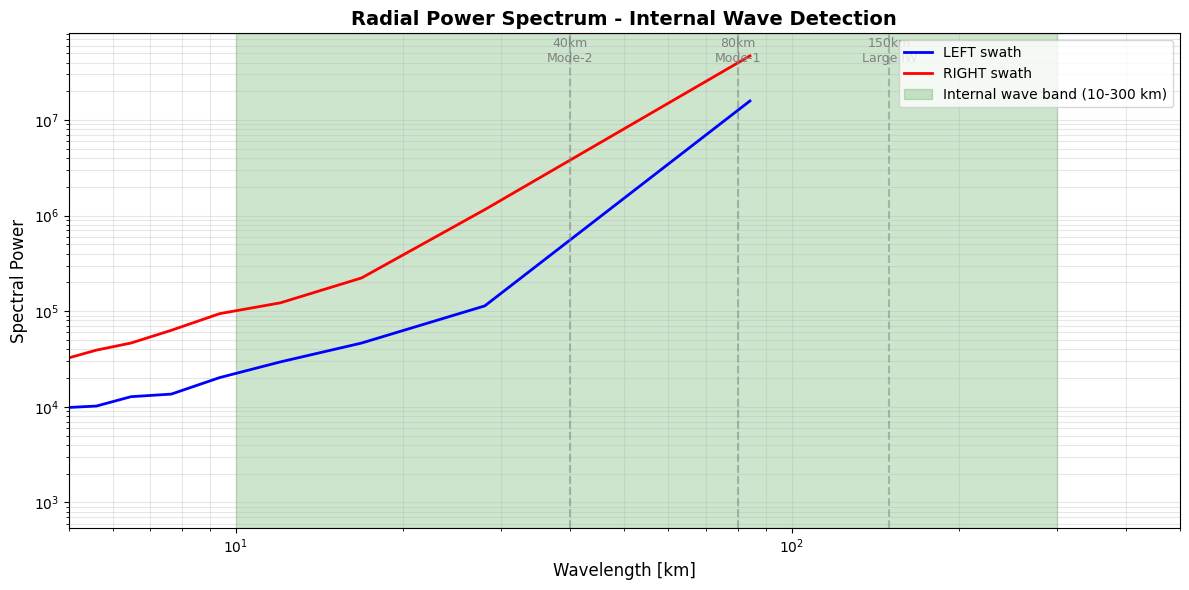

In [9]:
# =============================================================================
# RADIAL POWER SPECTRUM (1D)
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

colors = {'left': 'blue', 'right': 'red'}

for swath in fft_results:
    fft_res = fft_results[swath]
    wavelength = fft_res['radial_wavelength']
    power = fft_res['radial_power']
    
    # Filter valid wavelengths
    valid = (wavelength > 1) & (wavelength < 500) & (power > 0)
    
    ax.loglog(wavelength[valid], power[valid], '-', 
              color=colors[swath], linewidth=2, label=f'{swath.upper()} swath')

# Mark internal wave wavelength range
ax.axvspan(MIN_WAVELENGTH_KM, MAX_WAVELENGTH_KM, alpha=0.2, color='green', 
           label=f'Internal wave band ({MIN_WAVELENGTH_KM}-{MAX_WAVELENGTH_KM} km)')

# Mark typical Andaman Sea internal wave wavelengths
for wl, name in [(80, 'Mode-1'), (40, 'Mode-2'), (150, 'Large IW')]:
    ax.axvline(x=wl, color='gray', linestyle='--', alpha=0.5)
    ax.text(wl, ax.get_ylim()[1]*0.5, f'{wl}km\n{name}', 
            ha='center', fontsize=9, color='gray')

ax.set_xlabel('Wavelength [km]', fontsize=12)
ax.set_ylabel('Spectral Power', fontsize=12)
ax.set_title('Radial Power Spectrum - Internal Wave Detection', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(5, 500)

plt.tight_layout()
plt.show()

In [10]:
# =============================================================================
# BANDPASS FILTER FOR INTERNAL WAVES
# =============================================================================

def bandpass_filter_internal_waves(ssha, pixel_resolution_m=250,
                                    min_wavelength_km=50, max_wavelength_km=200):
    """
    Apply bandpass filter to isolate internal wave signatures.
    """
    # Replace NaN with 0
    ssha_filled = np.nan_to_num(ssha, nan=0.0)
    nan_mask = np.isnan(ssha)
    
    # Compute 2D FFT
    fft_result = fft2(ssha_filled)
    fft_shifted = fftshift(fft_result)
    
    # Create frequency grid
    n_along, n_across = ssha.shape
    freq_along = fftshift(fftfreq(n_along, d=pixel_resolution_m))
    freq_across = fftshift(fftfreq(n_across, d=pixel_resolution_m))
    freq_along_2d, freq_across_2d = np.meshgrid(freq_along, freq_across, indexing='ij')
    freq_radial = np.sqrt(freq_along_2d**2 + freq_across_2d**2)
    
    # Convert wavelength bounds to frequency
    freq_min = 1 / (max_wavelength_km * 1000)  # cycles/m
    freq_max = 1 / (min_wavelength_km * 1000)  # cycles/m
    
    # Create bandpass filter (smooth edges using Butterworth-like taper)
    filter_mask = np.zeros_like(freq_radial)
    in_band = (freq_radial >= freq_min) & (freq_radial <= freq_max)
    filter_mask[in_band] = 1.0
    
    # Apply Gaussian smoothing to filter edges
    filter_mask = gaussian_filter(filter_mask, sigma=2)
    
    # Apply filter
    fft_filtered = fft_shifted * filter_mask
    
    # Inverse FFT
    fft_unshifted = fftshift(fft_filtered)  # Undo the shift
    ssha_filtered = np.real(np.fft.ifft2(fft_unshifted))
    
    # Restore NaN mask
    ssha_filtered = np.where(nan_mask, np.nan, ssha_filtered)
    
    return ssha_filtered, filter_mask

# Apply bandpass filter to isolate internal waves
filtered_data = {}

for swath in regional_data:
    print(f"Filtering {swath.upper()} swath for internal waves...")
    ssha = regional_data[swath]['ssha']
    
    ssha_iw, filter_mask = bandpass_filter_internal_waves(
        ssha,
        pixel_resolution_m=PIXEL_RESOLUTION_M,
        min_wavelength_km=50,
        max_wavelength_km=200
    )
    
    filtered_data[swath] = {
        'ssha_iw': ssha_iw,
        'filter_mask': filter_mask
    }
    
    print(f"  IW signal range: {np.nanmin(ssha_iw)*100:.2f} to {np.nanmax(ssha_iw)*100:.2f} cm")
    print(f"  IW signal std: {np.nanstd(ssha_iw)*100:.2f} cm")

print("\n✓ Bandpass filtering complete!")

Filtering LEFT swath for internal waves...
  IW signal range: -12.58 to 10.00 cm
  IW signal std: 6.03 cm
Filtering RIGHT swath for internal waves...
  IW signal range: -37.27 to 15.12 cm
  IW signal std: 7.49 cm

✓ Bandpass filtering complete!


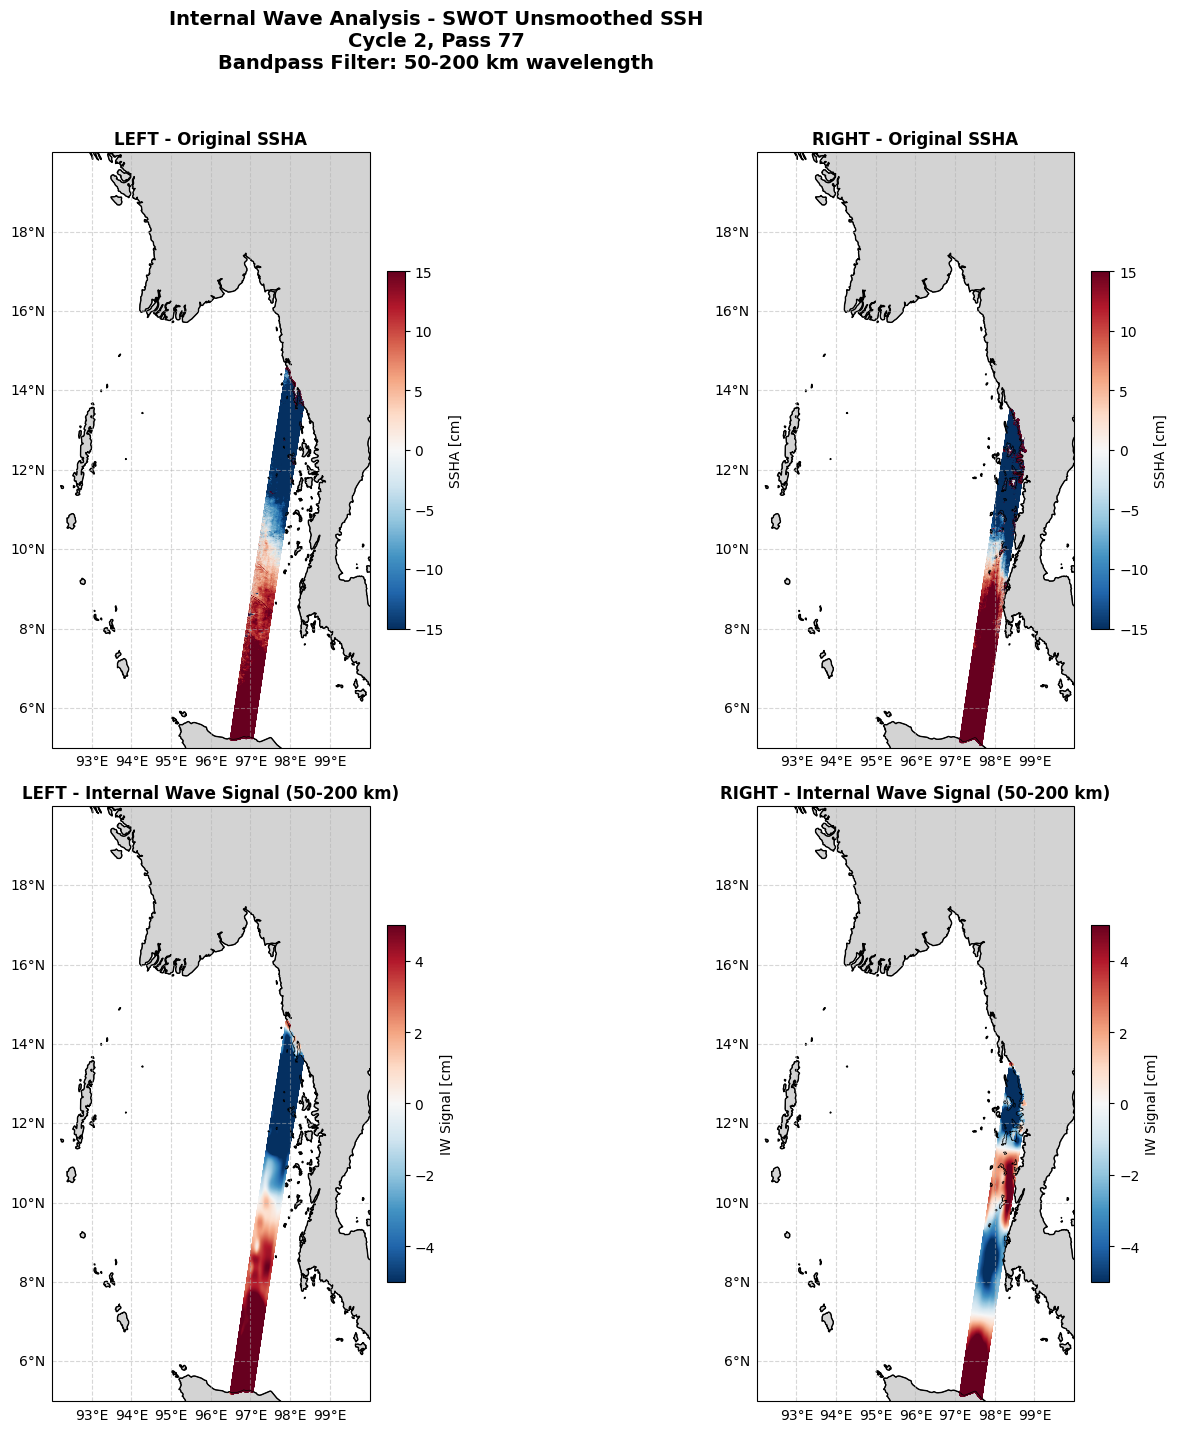

In [11]:
# =============================================================================
# VISUALIZE INTERNAL WAVE SIGNATURES
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14),
                          subplot_kw=dict(projection=ccrs.PlateCarree()))

for idx, swath in enumerate(regional_data):
    data = regional_data[swath]
    lat, lon = data['lat'], data['lon']
    ssha_orig = data['ssha']
    ssha_iw = filtered_data[swath]['ssha_iw']
    
    valid = ~np.isnan(ssha_orig)
    
    # Top row: Original SSHA
    ax = axes[0, idx]
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    
    sc = ax.scatter(lon[valid], lat[valid], c=ssha_orig[valid]*100, 
                    s=0.5, cmap='RdBu_r', vmin=-15, vmax=15,
                    transform=ccrs.PlateCarree())
    
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])
    ax.set_title(f'{swath.upper()} - Original SSHA', fontsize=12, fontweight='bold')
    gl = ax.gridlines(draw_labels=True, alpha=0.5, linestyle='--')
    gl.right_labels = gl.top_labels = False
    cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('SSHA [cm]')
    
    # Bottom row: Filtered Internal Wave signal
    ax = axes[1, idx]
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    
    valid_iw = ~np.isnan(ssha_iw)
    sc = ax.scatter(lon[valid_iw], lat[valid_iw], c=ssha_iw[valid_iw]*100, 
                    s=0.5, cmap='RdBu_r', vmin=-5, vmax=5,
                    transform=ccrs.PlateCarree())
    
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])
    ax.set_title(f'{swath.upper()} - Internal Wave Signal (50-200 km)', 
                 fontsize=12, fontweight='bold')
    gl = ax.gridlines(draw_labels=True, alpha=0.5, linestyle='--')
    gl.right_labels = gl.top_labels = False
    cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('IW Signal [cm]')

plt.suptitle(f'Internal Wave Analysis - SWOT Unsmoothed SSH\n'
             f'Cycle {result["metadata"]["cycle_number"]}, Pass {result["metadata"]["pass_number"]}\n'
             f'Bandpass Filter: 50-200 km wavelength',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

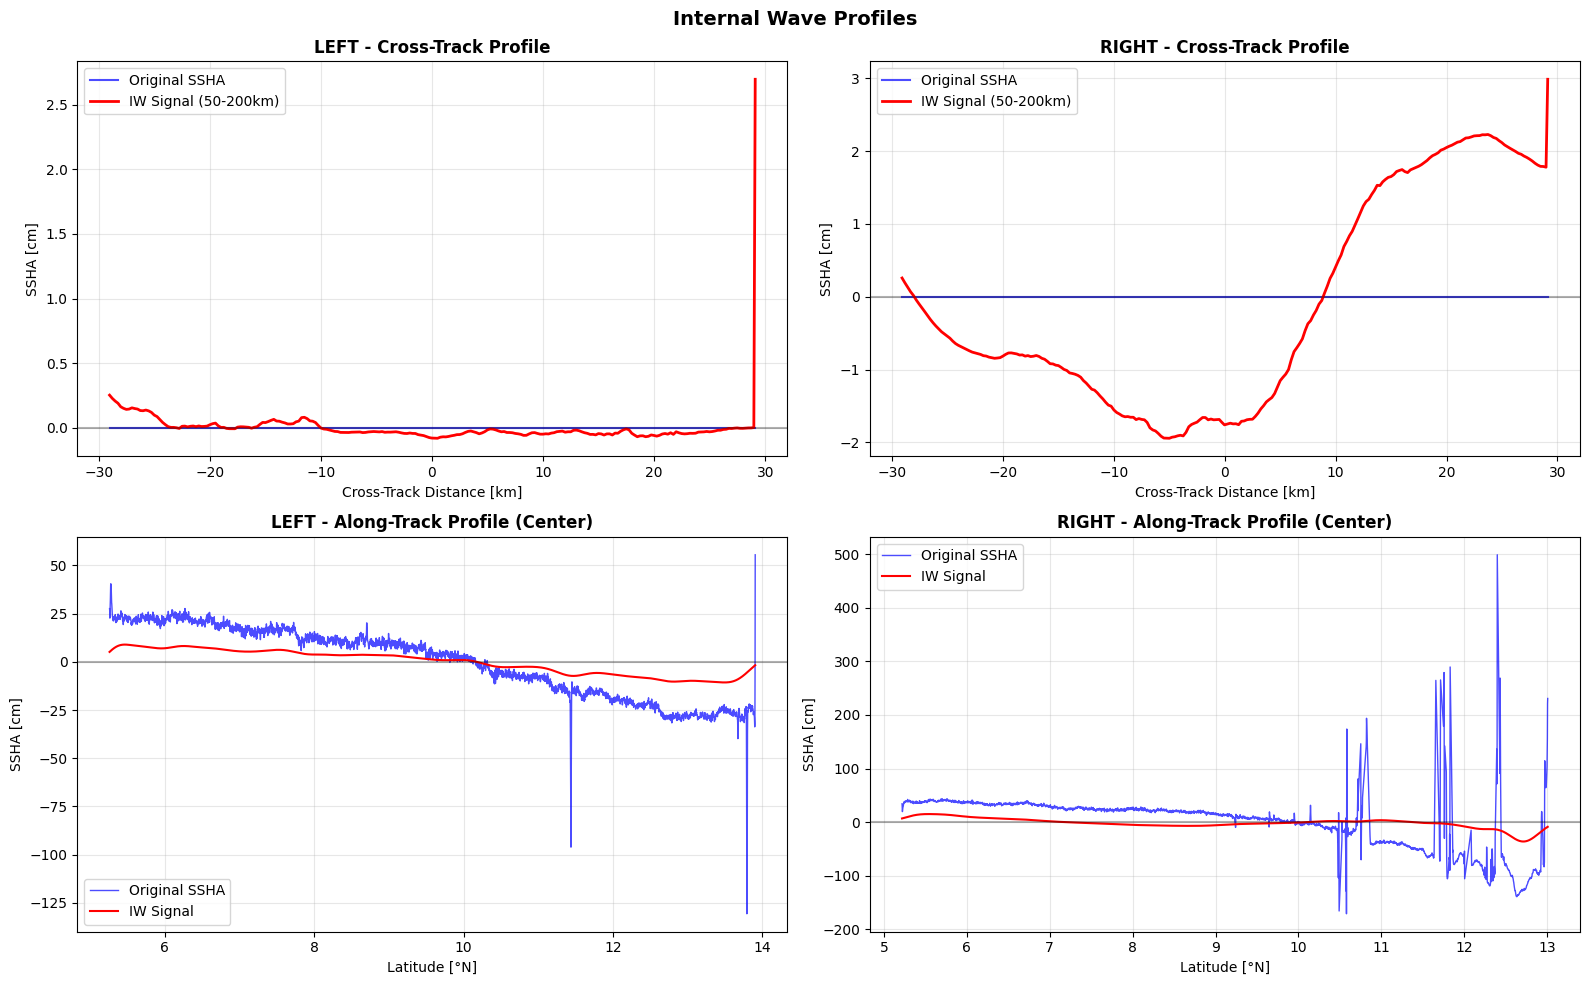

In [12]:
# =============================================================================
# CROSS-TRACK PROFILE ANALYSIS
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, swath in enumerate(regional_data):
    data = regional_data[swath]
    ssha = data['ssha']
    ssha_iw = filtered_data[swath]['ssha_iw']
    ctd = data['cross_track_dist'] / 1000  # Convert to km
    lat = data['lat']
    
    # Mean cross-track profile
    ctd_mean = np.nanmean(ctd, axis=0)
    ssha_profile = np.nanmean(ssha, axis=0) * 100  # cm
    ssha_iw_profile = np.nanmean(ssha_iw, axis=0) * 100  # cm
    
    # Top: Cross-track profile
    ax = axes[0, idx]
    ax.plot(ctd_mean, ssha_profile, 'b-', linewidth=1.5, label='Original SSHA', alpha=0.7)
    ax.plot(ctd_mean, ssha_iw_profile, 'r-', linewidth=2, label='IW Signal (50-200km)')
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.set_xlabel('Cross-Track Distance [km]', fontsize=10)
    ax.set_ylabel('SSHA [cm]', fontsize=10)
    ax.set_title(f'{swath.upper()} - Cross-Track Profile', fontsize=12, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    # Bottom: Along-track profile (at swath center)
    ax = axes[1, idx]
    center_col = ssha.shape[1] // 2
    lat_profile = lat[:, center_col]
    ssha_along = ssha[:, center_col] * 100
    ssha_iw_along = ssha_iw[:, center_col] * 100
    
    valid = ~np.isnan(ssha_along)
    ax.plot(lat_profile[valid], ssha_along[valid], 'b-', linewidth=1, 
            label='Original SSHA', alpha=0.7)
    ax.plot(lat_profile[valid], ssha_iw_along[valid], 'r-', linewidth=1.5, 
            label='IW Signal')
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.set_xlabel('Latitude [°N]', fontsize=10)
    ax.set_ylabel('SSHA [cm]', fontsize=10)
    ax.set_title(f'{swath.upper()} - Along-Track Profile (Center)', fontsize=12, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle('Internal Wave Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# =============================================================================
# INTERNAL WAVE STATISTICS SUMMARY
# =============================================================================

print("=" * 70)
print("INTERNAL WAVE ANALYSIS SUMMARY")
print("=" * 70)
print(f"\nFile: {filename}")
print(f"Cycle: {result['metadata']['cycle_number']}, Pass: {result['metadata']['pass_number']}")
print(f"Region: Andaman Sea ({LAT_MIN}°-{LAT_MAX}°N, {LON_MIN}°-{LON_MAX}°E)")

for swath in regional_data:
    print(f"\n--- {swath.upper()} SWATH ---")
    
    ssha = regional_data[swath]['ssha']
    ssha_iw = filtered_data[swath]['ssha_iw']
    fft_res = fft_results[swath]
    
    # Statistics
    print(f"  Valid points: {np.sum(~np.isnan(ssha)):,}")
    print(f"  Original SSHA std: {np.nanstd(ssha)*100:.2f} cm")
    print(f"  IW signal std: {np.nanstd(ssha_iw)*100:.2f} cm")
    print(f"  IW signal range: {np.nanmin(ssha_iw)*100:.2f} to {np.nanmax(ssha_iw)*100:.2f} cm")
    
    # Spectral power
    iw_fraction = fft_res['iw_power'] / fft_res['total_power'] * 100
    print(f"  IW band power fraction: {iw_fraction:.1f}%")
    
    # Find dominant wavelength
    valid_wl = (fft_res['radial_wavelength'] > 10) & (fft_res['radial_wavelength'] < 300)
    if np.any(valid_wl):
        max_power_idx = np.argmax(fft_res['radial_power'][valid_wl])
        dominant_wl = fft_res['radial_wavelength'][valid_wl][max_power_idx]
        print(f"  Dominant wavelength: ~{dominant_wl:.0f} km")

print("\n" + "=" * 70)
print("✓ Analysis complete!")
print("=" * 70)

INTERNAL WAVE ANALYSIS SUMMARY

File: SWOT_L2_LR_SSH_Unsmoothed_002_077_20230813T192851_20230813T202018_PGC0_01.nc
Cycle: 2, Pass: 77
Region: Andaman Sea (5.0°-20.0°N, 92.0°-100.0°E)

--- LEFT SWATH ---
  Valid points: 967,696
  Original SSHA std: 23.76 cm
  IW signal std: 6.03 cm
  IW signal range: -12.58 to 10.00 cm
  IW band power fraction: 26.7%
  Dominant wavelength: ~84 km

--- RIGHT SWATH ---
  Valid points: 815,226
  Original SSHA std: 44.15 cm
  IW signal std: 7.49 cm
  IW signal range: -37.27 to 15.12 cm
  IW band power fraction: 26.7%
  Dominant wavelength: ~84 km

✓ Analysis complete!


In [14]:
# =============================================================================
# BATCH ANALYSIS - PROCESS MULTIPLE FILES
# =============================================================================

def analyze_file_for_internal_waves(filepath, lat_bounds, lon_bounds, 
                                     pixel_resolution=250):
    """
    Analyze a single file for internal wave signatures.
    Returns summary statistics.
    """
    try:
        # Process file
        result = process_file(filepath, lat_bounds=lat_bounds, apply_ocean_mask=True)
        
        summary = {
            'filename': os.path.basename(filepath),
            'cycle': result['metadata']['cycle_number'],
            'pass': result['metadata']['pass_number'],
            'time': result['metadata']['time_coverage_start'],
        }
        
        for swath in ['left', 'right']:
            # Extract regional data
            lat, lon, ssha, ctd = extract_regional_grid(
                result, lat_bounds, lon_bounds, swath
            )
            
            if ssha is None or np.sum(~np.isnan(ssha)) < 1000:
                summary[f'{swath}_valid'] = False
                continue
            
            summary[f'{swath}_valid'] = True
            summary[f'{swath}_points'] = int(np.sum(~np.isnan(ssha)))
            summary[f'{swath}_ssha_std'] = float(np.nanstd(ssha))
            
            # FFT analysis
            fft_res = analyze_internal_waves_fft(
                ssha, pixel_resolution_m=pixel_resolution,
                min_wavelength_km=MIN_WAVELENGTH_KM,
                max_wavelength_km=MAX_WAVELENGTH_KM
            )
            
            summary[f'{swath}_iw_power_fraction'] = float(
                fft_res['iw_power'] / fft_res['total_power'] * 100
            )
            
            # Bandpass filter
            ssha_iw, _ = bandpass_filter_internal_waves(
                ssha, pixel_resolution_m=pixel_resolution,
                min_wavelength_km=50, max_wavelength_km=200
            )
            summary[f'{swath}_iw_std'] = float(np.nanstd(ssha_iw))
        
        return summary
        
    except Exception as e:
        return {
            'filename': os.path.basename(filepath),
            'error': str(e)
        }

# Analyze first 5 files as example
print("Batch analyzing files for internal waves...\n")

batch_results = []
n_files = min(5, len(files))  # Limit to 5 for demo

for i in range(n_files):
    print(f"[{i+1}/{n_files}] {os.path.basename(files[i])}")
    
    summary = analyze_file_for_internal_waves(
        files[i],
        lat_bounds=(LAT_MIN, LAT_MAX),
        lon_bounds=(LON_MIN, LON_MAX)
    )
    
    batch_results.append(summary)
    
    if 'error' not in summary:
        for swath in ['left', 'right']:
            if summary.get(f'{swath}_valid', False):
                print(f"    {swath}: IW power {summary[f'{swath}_iw_power_fraction']:.1f}%, "
                      f"IW std {summary[f'{swath}_iw_std']*100:.2f} cm")
    else:
        print(f"    Error: {summary['error']}")

print(f"\n✓ Analyzed {n_files} files")

Batch analyzing files for internal waves...

[1/5] SWOT_L2_LR_SSH_Unsmoothed_002_077_20230813T192851_20230813T202018_PGC0_01.nc
    left: IW power 26.7%, IW std 6.03 cm
    right: IW power 26.7%, IW std 7.49 cm
[2/5] SWOT_L2_LR_SSH_Unsmoothed_003_077_20230903T161357_20230903T170523_PGC0_01.nc
    left: IW power 17.4%, IW std 6.13 cm
    right: IW power 7.6%, IW std 9.28 cm
[3/5] SWOT_L2_LR_SSH_Unsmoothed_005_077_20231015T094404_20231015T101050_PGC0_01.nc
[4/5] SWOT_L2_LR_SSH_Unsmoothed_006_077_20231105T062909_20231105T072036_PGC0_01.nc
    left: IW power 28.9%, IW std 2.50 cm
    right: IW power 9.9%, IW std 2.02 cm
[5/5] SWOT_L2_LR_SSH_Unsmoothed_007_077_20231126T031415_20231126T040542_PGC0_01.nc
    left: IW power 33.6%, IW std 8.28 cm
    right: IW power 32.2%, IW std 7.40 cm

✓ Analyzed 5 files


In [15]:
# =============================================================================
# SAVE ANALYSIS RESULTS
# =============================================================================

import pandas as pd
from datetime import datetime

# Convert batch results to DataFrame
df_results = pd.DataFrame(batch_results)

# Save to CSV
output_csv = os.path.join(
    r"C:\Users\abhik\Desktop\project related work",
    f"internal_wave_analysis_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
)

df_results.to_csv(output_csv, index=False)
print(f"✓ Results saved to: {output_csv}")

# Display summary
print("\nBatch Analysis Summary:")
display(df_results)

✓ Results saved to: C:\Users\abhik\Desktop\project related work\internal_wave_analysis_20260201_004029.csv

Batch Analysis Summary:


,filename,cycle,pass,time,left_valid,left_points,left_ssha_std,left_iw_power_fraction,left_iw_std,right_valid,right_points,right_ssha_std,right_iw_power_fraction,right_iw_std
0,SWOT_L2_LR_SSH_Unsmoothed_002_077_20230813T192...,2,77,2023-08-13T19:28:51.638914,True,967696.0,0.237639,26.722775,0.060330,True,815226.0,0.441488,26.667347,0.074883
1,SWOT_L2_LR_SSH_Unsmoothed_003_077_20230903T161...,3,77,2023-09-03T16:13:57.075932,True,962318.0,0.492298,17.384273,0.061312,True,807225.0,0.546803,7.622298,0.092837
2,SWOT_L2_LR_SSH_Unsmoothed_005_077_20231015T094...,5,77,2023-10-15T09:44:04.519314,False,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
3,SWOT_L2_LR_SSH_Unsmoothed_006_077_20231105T062...,6,77,2023-11-05T06:29:09.914326,True,968366.0,0.122921,28.922827,0.024950,True,813587.0,0.277237,9.864588,0.020240
4,SWOT_L2_LR_SSH_Unsmoothed_007_077_20231126T031...,7,77,2023-11-26T03:14:15.407250,True,967785.0,0.381888,33.556793,0.082835,True,811719.0,0.491917,32.207260,0.074035
